# Layer 1: HMM Regime Classifier Evaluation

Trains a 3-state Gaussian HMM to classify market regimes as Calm / Volatile / Stressed.

## Setup

In [1]:
%cd C:/Users/zihan/capstone

import sys
sys.path.insert(0, 'C:/Users/zihan/capstone')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.layer1_hmm.hmm_train import build_hmm_features, select_states, train_hmm
import joblib
from pathlib import Path

DATA_DIR = Path('data/processed')
MODEL_DIR = Path('models/hmm')
print('Libraries loaded')

C:\Users\zihan\capstone


Libraries loaded


## Load Processed Data

In [2]:
price_df = pd.read_parquet(DATA_DIR / 'price_features.parquet')
trades_df = pd.read_parquet(DATA_DIR / 'trades_processed.parquet')
print(f'Price data: {price_df.shape}')
print(f'Trades data: {trades_df.shape}')
print(f'Date range: {price_df["timestamp"].min()} to {price_df["timestamp"].max()}')

Price data: (8656, 20)
Trades data: (8656, 4)
Date range: 2026-03-05 00:00:00 to 2026-04-04 01:15:00


## Build HMM Features

In [3]:
features = build_hmm_features(price_df, trades_df)
X = features.values
print(f'Feature matrix shape: {X.shape}')
print(f'Features: {list(features.columns)}')

2026-04-04 11:26:52,879 INFO HMM feature matrix built: (8636, 4)


Feature matrix shape: (8636, 4)
Features: ['return', 'realized_vol', 'spread_proxy', 'ofi']


## State Selection (BIC/AIC)

In [4]:
scores, best_n = select_states(X)
print('BIC/AIC Results:')
for n, s in scores.items():
    print(f'  n_states={n}: BIC={s["bic"]:.2f}, AIC={s["aic"]:.2f}')
print(f'BIC selects: {best_n} states (project uses 3)')

2026-04-04 11:26:56,650 INFO   n_states=2: BIC=-111941.04, AIC=-112075.25


2026-04-04 11:26:56,833 WARNING Model is not converging.  Current: 63104.110945450564 is not greater than 63108.6042703316. Delta is -4.493324881033914


2026-04-04 11:26:57,529 WARNING Model is not converging.  Current: 59855.62018219975 is not greater than 59868.75592104723. Delta is -13.135738847478933


2026-04-04 11:26:57,807 INFO   n_states=3: BIC=-125912.27, AIC=-126138.31


2026-04-04 11:26:58,380 WARNING Model is not converging.  Current: 63209.39481032549 is not greater than 63213.387809495485. Delta is -3.992999169997347


2026-04-04 11:26:58,962 WARNING Model is not converging.  Current: 63098.92373324665 is not greater than 63099.77678859028. Delta is -0.8530553436285118


2026-04-04 11:26:59,176 WARNING Model is not converging.  Current: 63212.908049240905 is not greater than 63217.45709514954. Delta is -4.54904590863589


2026-04-04 11:26:59,192 INFO   n_states=4: BIC=-129944.19, AIC=-130276.18


2026-04-04 11:26:59,193 INFO Best state count (BIC): 4


BIC/AIC Results:
  n_states=2: BIC=-111941.04, AIC=-112075.25
  n_states=3: BIC=-125912.27, AIC=-126138.31
  n_states=4: BIC=-129944.19, AIC=-130276.18
BIC selects: 4 states (project uses 3)


## Train Final HMM (3 states)

In [5]:
model = train_hmm(X, n_states=3)
joblib.dump(model, MODEL_DIR / 'hmm_model.pkl')
print(f'Model saved. Log-likelihood: {model.score(X):.2f}')

2026-04-04 11:26:59,367 WARNING Model is not converging.  Current: 63104.110945422624 is not greater than 63108.60427036679. Delta is -4.493324944167398


2026-04-04 11:27:00,119 WARNING Model is not converging.  Current: 59855.62018219975 is not greater than 59868.75592104723. Delta is -13.135738847478933


2026-04-04 11:27:00,416 INFO HMM trained: 3 states, log-likelihood=63101.15


2026-04-04 11:27:00,444 INFO State labels: {np.int64(1): 'Calm', np.int64(2): 'Volatile', np.int64(0): 'Stressed'}


Model saved. Log-likelihood: 63101.15


## State Labeling Validation

In [6]:
hidden_states = model.predict(X)
regime_series = pd.Series(hidden_states).map(model.state_labels_)
regime_series.index = features.index

print('State means (return, realized_vol, spread_proxy, ofi):')
for state_id, label in sorted(model.state_labels_.items(), key=lambda x: model.means_[x[0], 1]):
    means = model.means_[state_id]
    print(f'  {label}: return={means[0]:.6f}, vol={means[1]:.6f}')

print('\nRegime distribution:')
print(regime_series.value_counts())

State means (return, realized_vol, spread_proxy, ofi):
  Calm: return=-0.000036, vol=0.002329
  Volatile: return=-0.000027, vol=0.002591
  Stressed: return=0.055639, vol=0.247777

Regime distribution:
Calm        7236
Volatile    1380
Stressed      20
Name: count, dtype: int64


## Visualization

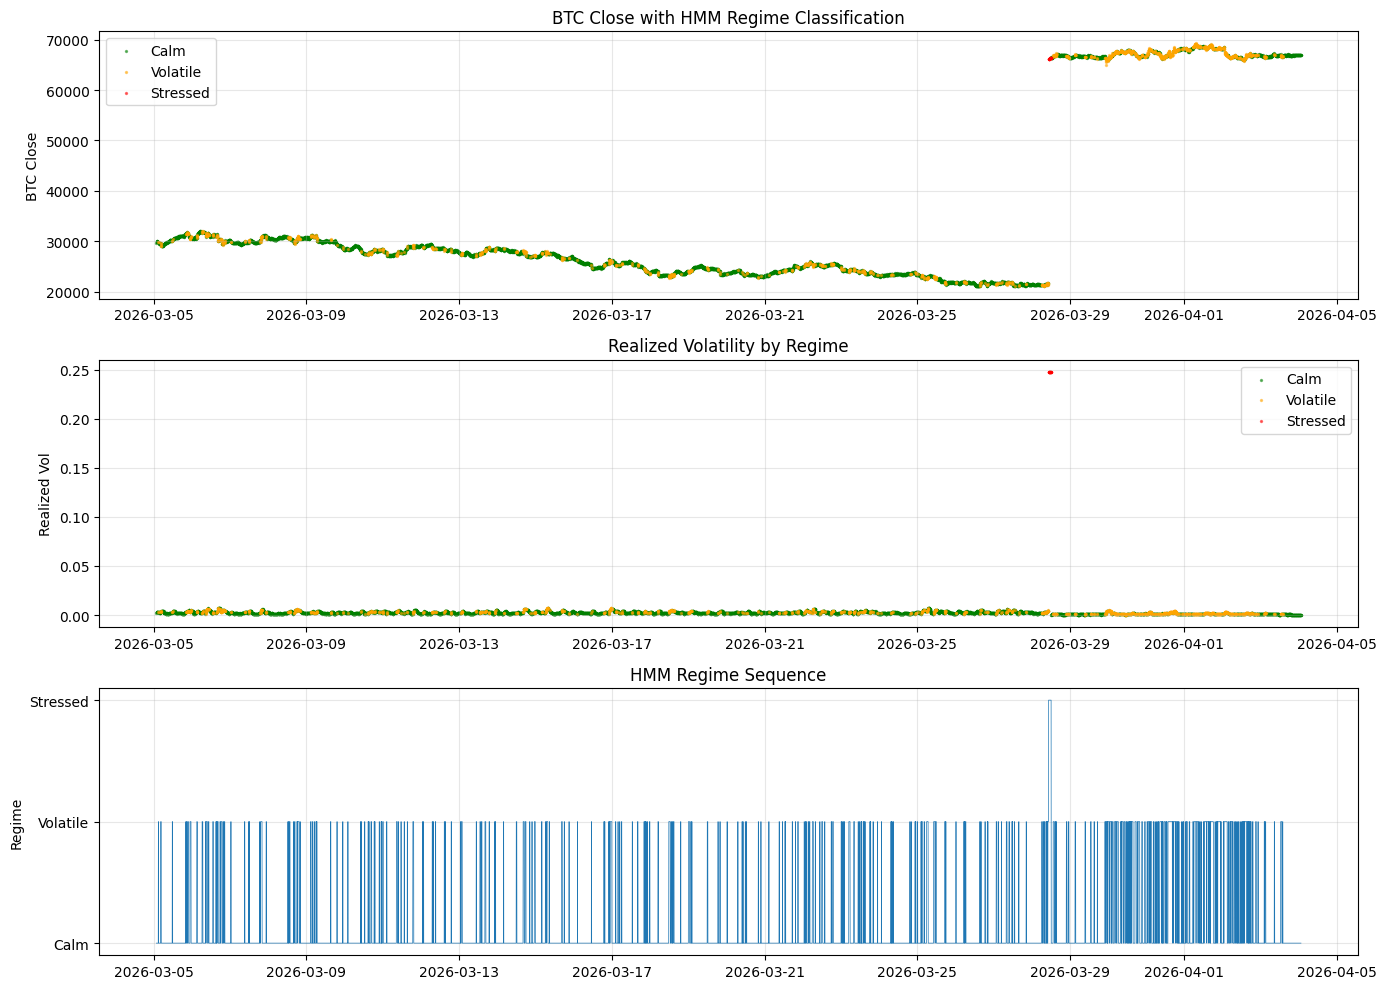

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
colors = {'Calm': 'green', 'Volatile': 'orange', 'Stressed': 'red'}

# Align price_df to features index for proper plotting
price_aligned = price_df.set_index('timestamp')

ax = axes[0]
for regime in ['Calm', 'Volatile', 'Stressed']:
    mask = regime_series == regime
    ax.scatter(regime_series.index[mask], price_aligned.loc[regime_series.index[mask], 'close'],
               c=colors[regime], s=2, alpha=0.5, label=regime)
ax.set_ylabel('BTC Close')
ax.set_title('BTC Close with HMM Regime Classification')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for regime in ['Calm', 'Volatile', 'Stressed']:
    mask = regime_series == regime
    ax.scatter(regime_series.index[mask], features.loc[regime_series.index[mask], 'realized_vol'],
               c=colors[regime], s=2, alpha=0.5, label=regime)
ax.set_ylabel('Realized Vol')
ax.set_title('Realized Volatility by Regime')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
regime_num = regime_series.map({'Calm': 0, 'Volatile': 1, 'Stressed': 2})
ax.plot(regime_series.index, regime_num, linewidth=0.5)
ax.set_ylabel('Regime')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Calm', 'Volatile', 'Stressed'])
ax.set_title('HMM Regime Sequence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'hmm_regime_plots.png', dpi=150)
plt.show()

## Transition Analysis

Regime Transition Matrix (row=t-1, col=t):
col_0      Calm  Stressed  Volatile
row_0                              
Calm      0.955     0.000     0.045
Stressed  0.050     0.950     0.000
Volatile  0.236     0.001     0.763


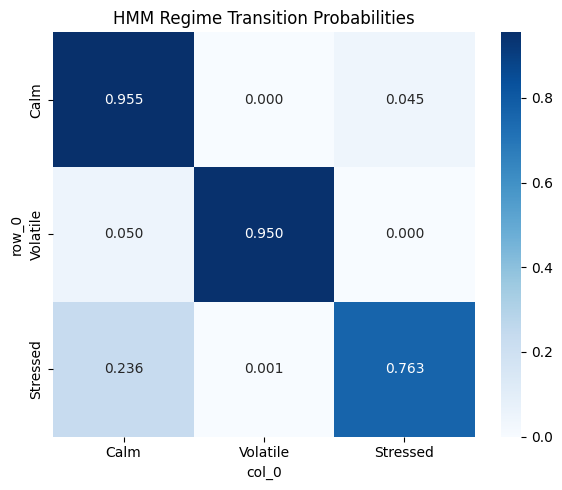

In [8]:
transition_df = pd.crosstab(
    regime_series.shift(1).ffill(),
    regime_series, normalize='index'
)
print('Regime Transition Matrix (row=t-1, col=t):')
print(transition_df.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(transition_df, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            xticklabels=['Calm', 'Volatile', 'Stressed'],
            yticklabels=['Calm', 'Volatile', 'Stressed'])
ax.set_title('HMM Regime Transition Probabilities')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'hmm_transitions.png', dpi=150)
plt.show()

## Save Regime Labels

In [9]:
# Create full regime series aligned to price_df timestamps
# features now has DatetimeIndex (timestamp)
full_regime = pd.Series(index=price_df['timestamp'], dtype=object)
full_regime.loc[features.index] = regime_series
full_regime = full_regime.ffill().bfill()
full_regime.to_csv(MODEL_DIR / 'regime_labels.csv', header=True)
print(f'Regime labels saved.\n{full_regime.value_counts()}')

Regime labels saved.
Calm        7256
Volatile    1380
Stressed      20
Name: count, dtype: int64


## Limitations
- BIC prefers 4 states; project constrains to 3 for interpretability
- Stressed regime is rare due to limited crisis data
- Non-convergence warnings; multiple restarts used
- Data is hybrid: recent real Binance OHLCV + synthetic historical